In [8]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import math

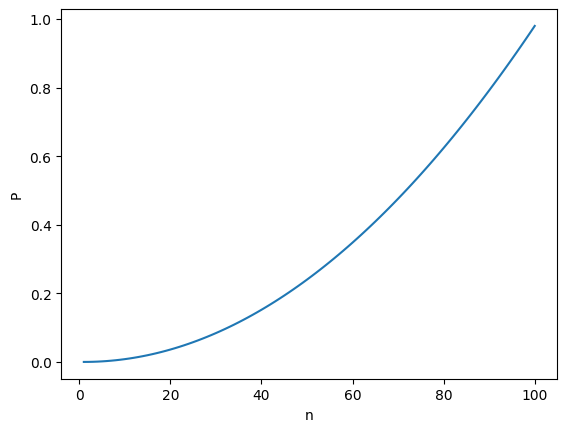

In [19]:
# funkcja dodajaca do ciagu bit parzystosci
def dod_bit_parz(u):
    m = len(u)
    bit = 0
    for j in range(m):
        bit = np.mod(int(u[j])+bit,2)
    return [u,bit]

# funkcja rysujaca wykres zaleznosci stosowania i niestosowania kodow dla zadanej wartosci p

def prawd_kontr_parz(P):
    nmin=1
    krok = 1
    nmax = 100

    n= np.arange(nmin,nmax+1,krok)

    p1 = ((n-1)*P) * ((1-P) * (n-1))
    plt.figure(1)
    plt.xlabel('n')
    plt.ylabel('P')
    plt.plot(n,p1)
    plt.show()

prawd_kontr_parz(0.0001)

In [6]:
def gen_kod_lin(G):
    G = np.array(G)
    k, n = G.shape

    if k > n:
        print("Błędna macierz generująca! k > n")
        return None, None

    dmin = n
    X = []

    for bits in product([0, 1], repeat=k):
        u = np.array(bits)
        x = np.mod(u @ G, 2)
        X.append(x)

        print(f"u = {u} odpowiada x = {x}")

        d = np.sum(x)  # waga Hamminga
        if np.any(u) and dmin > d:
            dmin = d

    X = np.array(X)
    return X, dmin

def ham_cod_corr(y):
    y = np.array(y)
    n = len(y)

    r = math.log2(n + 1)

    if r != int(r):
        print("To nie jest odpowiednia długość słowa kodowego!")
        return None

    r = int(r)
    k = n - r

    print(f"To jest kod ({n},{k}) o macierzy testów parzystości:")

    # budowanie macierzy H
    H = np.array([[0] for _ in range(r-1)] + [[1]])

    for i in range(2, 2**r):
        col = np.array(list(map(int, format(i, f'0{r}b')))).reshape(r,1)
        H = np.hstack((H, col))

    print(H)

    # obliczanie syndromu
    syndrom = np.mod(y @ H.T, 2)

    print(f"Syndrom dla y = {y} to s = {syndrom}, zatem:")

    if np.mean(syndrom) == 0:
        print("przyjmujemy, że nie wystąpiło przekłamanie.")
        return y
    else:
        pozycja = int("".join(map(str, syndrom)), 2)

        print(f"przyjmujemy, że przekłamanie wystąpiło na pozycji nr {pozycja}")

        y[pozycja - 1] = (y[pozycja - 1] + 1) % 2
        x = y

        print(f"a wysłano słowo kodowe {x}")

        return x

In [9]:
# Wyznaczanie ciagow kodowych na podstawie macierzy G

G = [
    [1,0,0,1],
    [0,1,0,1],
    [0,0,1,1]
]
X, dmin = gen_kod_lin(G)
print("Słowa kodowe:")
print(X)
print("Minimalna odległość:", dmin)

# Korekcja błędów jednokrotnych za pomoca Hamminga

y = [1,0,1,1,0,1,0]
x = ham_cod_corr(y)
print("Poprawione słowo:", x)

u = [0 0 0] odpowiada x = [0 0 0 0]
u = [0 0 1] odpowiada x = [0 0 1 1]
u = [0 1 0] odpowiada x = [0 1 0 1]
u = [0 1 1] odpowiada x = [0 1 1 0]
u = [1 0 0] odpowiada x = [1 0 0 1]
u = [1 0 1] odpowiada x = [1 0 1 0]
u = [1 1 0] odpowiada x = [1 1 0 0]
u = [1 1 1] odpowiada x = [1 1 1 1]
Słowa kodowe:
[[0 0 0 0]
 [0 0 1 1]
 [0 1 0 1]
 [0 1 1 0]
 [1 0 0 1]
 [1 0 1 0]
 [1 1 0 0]
 [1 1 1 1]]
Minimalna odległość: 2
To jest kod (7,4) o macierzy testów parzystości:
[[0 0 0 1 1 1 1]
 [0 1 1 0 0 1 1]
 [1 0 1 0 1 0 1]]
Syndrom dla y = [1 0 1 1 0 1 0] to s = [0 0 0], zatem:
przyjmujemy, że nie wystąpiło przekłamanie.
Poprawione słowo: [1 0 1 1 0 1 0]
